In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap joblib streamlit -q

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
useless_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=[c for c in useless_cols if c in df.columns])
print(df.shape)

(1470, 31)


In [6]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [7]:
missing = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Columns with missing values:")
print(missing[missing > 0] if (missing > 0).any() else "None — dataset is complete, no imputation needed.")
print("\nDuplicate rows:", df.duplicated().sum())

Columns with missing values:
None — dataset is complete, no imputation needed.

Duplicate rows: 0


Overall attrition rate: 16.1%


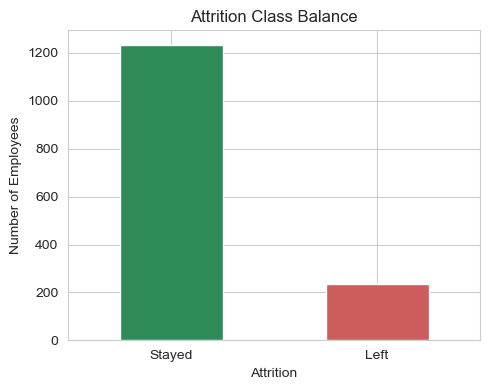

In [8]:
attrition_rate = df['Attrition'].mean() * 100
print(f"Overall attrition rate: {attrition_rate:.1f}%")

plt.figure(figsize=(5,4))
df['Attrition'].value_counts().plot(kind='bar', color=['seagreen', 'indianred'])
plt.xticks([0,1], ['Stayed', 'Left'], rotation=0)
plt.title('Attrition Class Balance')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

C:\Users\ayush\AppData\Local\Temp\ipykernel_5348\2431747256.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Stayed', 'Left'])
C:\Users\ayush\AppData\Local\Temp\ipykernel_5348\2431747256.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Stayed', 'Left'])
C:\Users\ayush\AppData\Local\Temp\ipykernel_5348\2431747256.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Stayed', 'Left'])
C:\Users\ayush\AppData\Local\Temp\ipykernel_5348\2431747256.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Stayed', 'Left'])
C:\Users\ayush\AppData\Local\Temp\ipyker

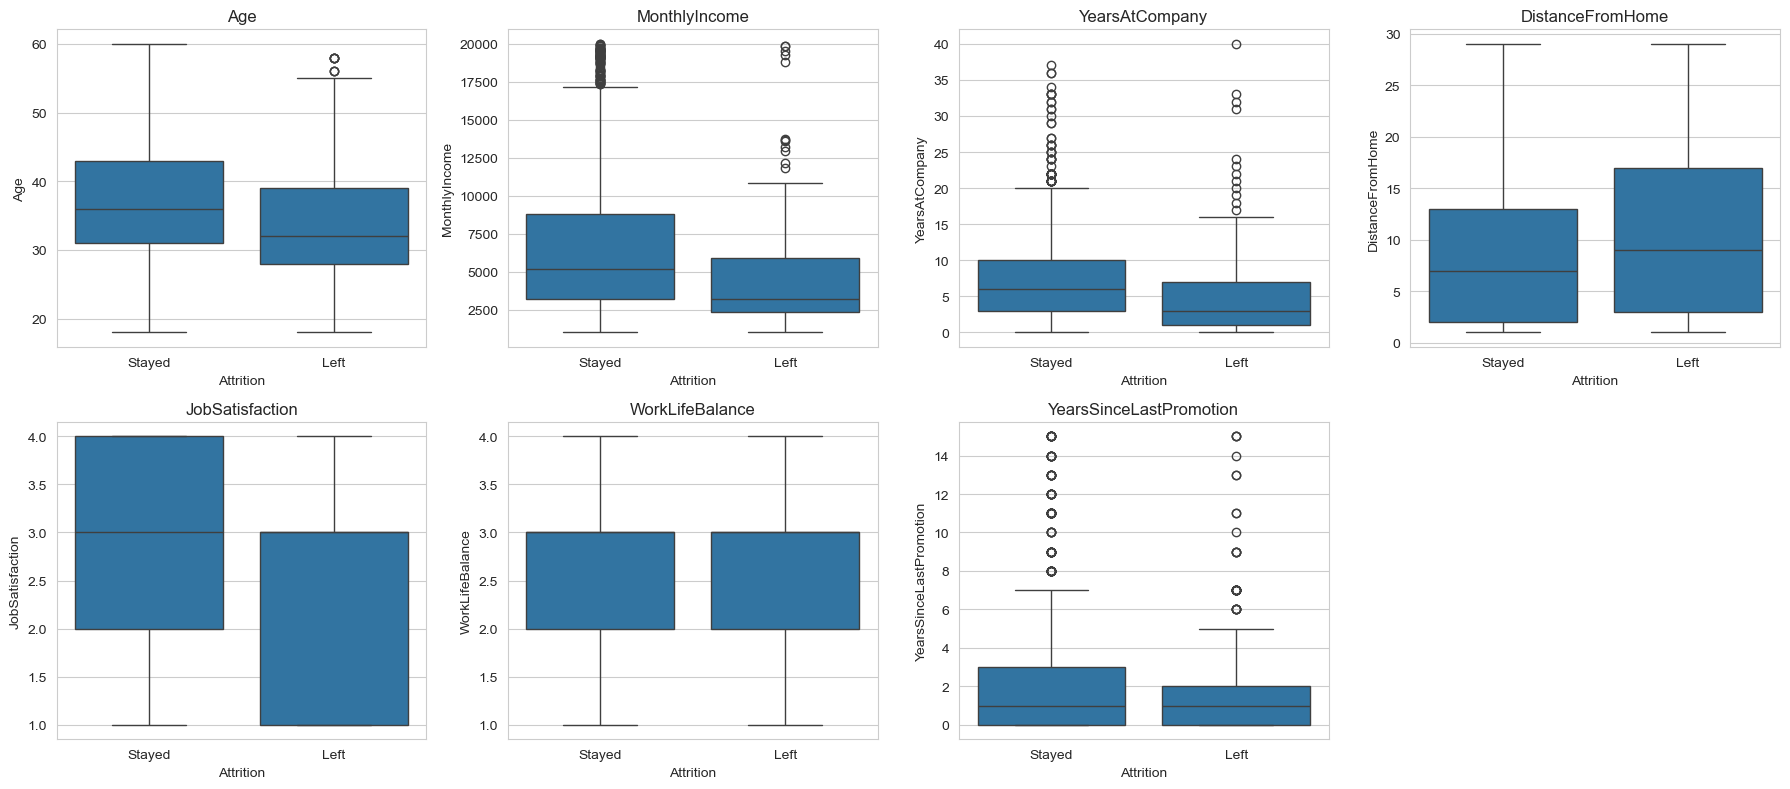

In [10]:
numeric_check = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
                  'JobSatisfaction', 'WorkLifeBalance', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_check):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i])
    axes[i].set_xticklabels(['Stayed', 'Left'])
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

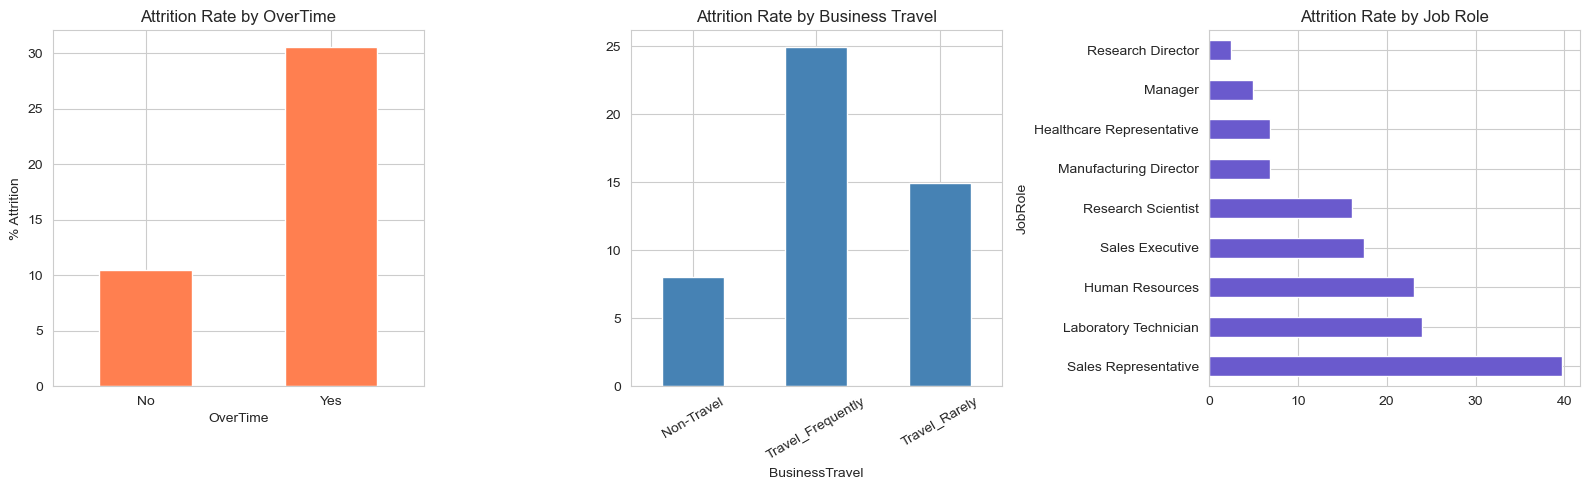

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

df.groupby('OverTime')['Attrition'].mean().mul(100).plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Attrition Rate by OverTime')
axes[0].set_ylabel('% Attrition')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('BusinessTravel')['Attrition'].mean().mul(100).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Attrition Rate by Business Travel')
axes[1].tick_params(axis='x', rotation=30)

df.groupby('JobRole')['Attrition'].mean().mul(100).sort_values(ascending=False).plot(kind='barh', ax=axes[2], color='slateblue')
axes[2].set_title('Attrition Rate by Job Role')

plt.tight_layout()
plt.show()

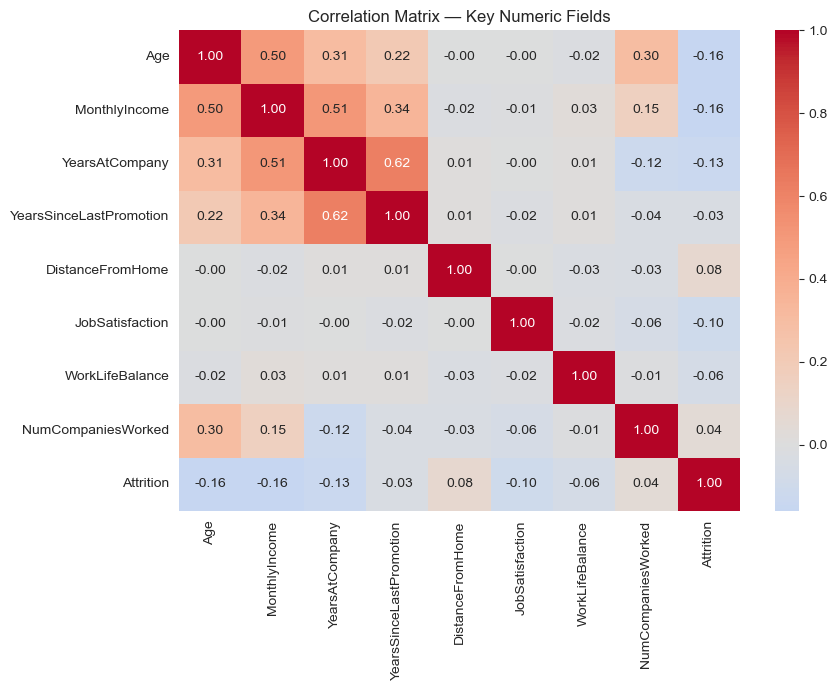

In [12]:
corr_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsSinceLastPromotion',
             'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance', 'NumCompaniesWorked', 'Attrition']

plt.figure(figsize=(9,7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Key Numeric Fields')
plt.tight_layout()
plt.show()

In [13]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.shape)

(1470, 45)


In [14]:
df_encoded['IncomePerYearAtCompany'] = df_encoded['MonthlyIncome'] / (df_encoded['YearsAtCompany'] + 1)
df_encoded['PromotionGap'] = df_encoded['YearsAtCompany'] - df_encoded['YearsSinceLastPromotion']

In [15]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

feature_columns = X.columns.tolist()
print(X_train.shape, X_test.shape)

(1176, 46) (294, 46)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(pd.Series(y_train_bal).value_counts())

Attrition
0    986
1    986
Name: count, dtype: int64


In [18]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_bal, y_train_bal)

y_pred_lr = logreg.predict(X_test_scaled)
y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       247
           1       0.38      0.60      0.47        47

    accuracy                           0.78       294
   macro avg       0.65      0.71      0.66       294
weighted avg       0.83      0.78      0.80       294

ROC-AUC: 0.7875786028081662


In [19]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb.fit(X_train_bal, y_train_bal)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294

ROC-AUC: 0.7695753294857438


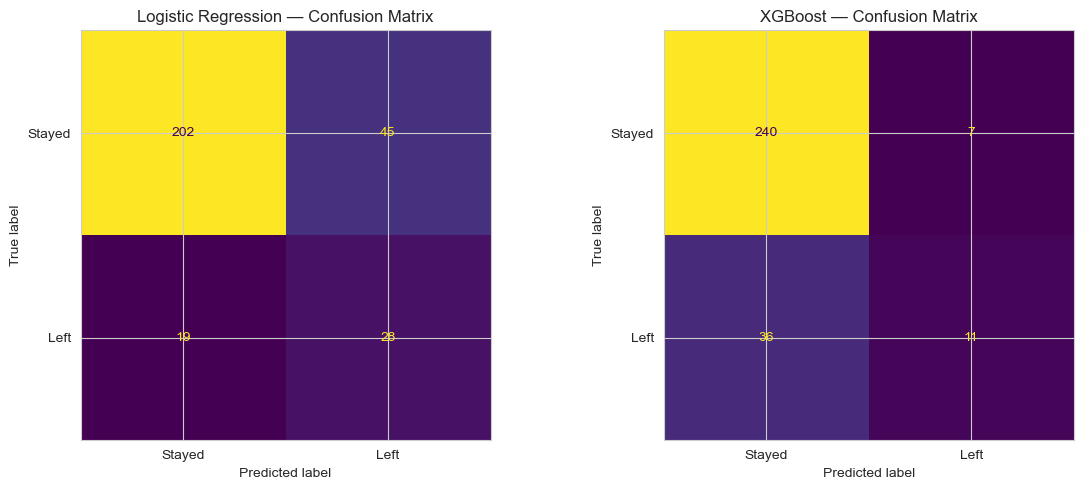

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Stayed','Left']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression — Confusion Matrix')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Stayed','Left']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('XGBoost — Confusion Matrix')

plt.tight_layout()
plt.show()

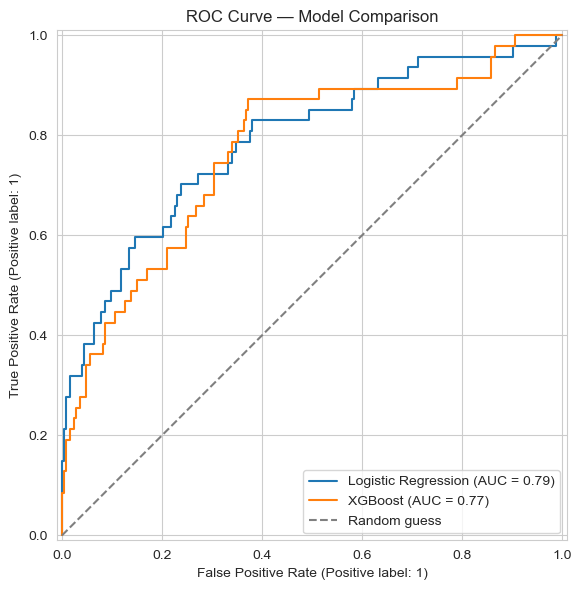

In [21]:
fig, ax = plt.subplots(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name='XGBoost', ax=ax)
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess')
ax.set_title('ROC Curve — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss'))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_train_scaled, y_train, cv=skf, scoring='roc_auc')

print("5-Fold CV ROC-AUC scores:", cv_scores.round(3))
print(f"Mean CV ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

5-Fold CV ROC-AUC scores: [0.781 0.747 0.866 0.83  0.774]
Mean CV ROC-AUC: 0.800 (+/- 0.043)


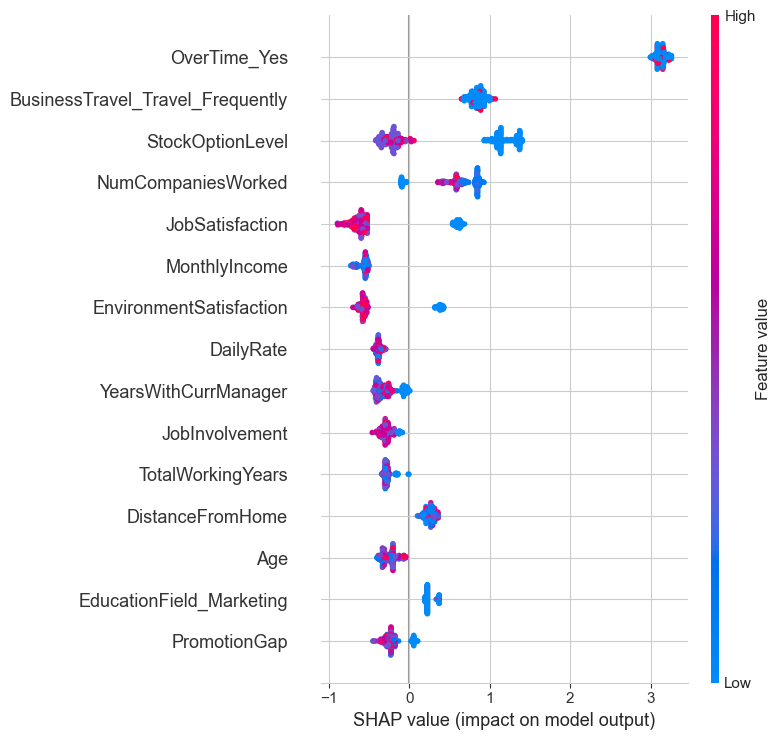

In [23]:
explainer = shap.TreeExplainer(xgb)

shap_values_all = explainer.shap_values(X_test)
shap.summary_plot(shap_values_all, X_test, feature_names=feature_columns, max_display=15, show=False)
plt.tight_layout()
plt.savefig("shap_summary_attrition.png", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
def get_top_shap_features(shap_row, feature_names, top_n=3):
    contributions = list(zip(feature_names, shap_row))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    return [(name, val, "increases risk" if val > 0 else "decreases risk") for name, val in contributions[:top_n]]

In [25]:
joblib.dump(xgb, "attrition_model.pkl")
joblib.dump(scaler, "attrition_scaler.pkl")
joblib.dump(feature_columns, "attrition_features.pkl")
print("Saved: attrition_model.pkl, attrition_scaler.pkl, attrition_features.pkl")

Saved: attrition_model.pkl, attrition_scaler.pkl, attrition_features.pkl


In [26]:
import os
print(os.getcwd())

C:\Users\ayush\Employee_Attrition
